# Procedural steps (Tasks)

Task#1: Thresholding
Step#1: Apply thresholding with a fixed threshold on an image:
* In image processing, thresholding is a common technique used to separate objects or
regions in an image based on their pixel intensities. It involves converting a grayscale or
color image into a binary image, where pixels are classified as either "foreground" or
"background" based on a specified threshold value.

* The threshold value acts as a dividing point, determining which pixels are considered part of
the foreground (above the threshold) and which are part of the background (below the
threshold). The process of thresholding essentially simplifies the image by reducing the pixel
values to two categories, simplifying subsequent analysis or feature extraction. The result of
thresholding is a binary image where foreground objects are represented by white pixels
and background areas are represented by black pixels.
* Thresholding can be used for various image processing tasks, such as image segmentation,
object detection, and feature extraction. Different thresholding techniques and algorithms
exist to handle specific scenarios, such as adaptive thresholding, where the threshold value
varies across different regions of the image.
* It's important to note that choosing an appropriate threshold value can be challenging, as it
depends on factors like image quality, lighting conditions, and the characteristics of the objects
or regions of interest. Experimentation and adjusting the threshold value may be necessary
to achieve desired results.

In [1]:
import cv2
# Load the image in grayscale
img = cv2.imread('Parrot.png', cv2.IMREAD_GRAYSCALE)
# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]
# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255,cv2.THRESH_BINARY)
cv2.imshow(f'Thresholded Image ({threshold_value})',
    thresh)
# Display the original image
cv2.imshow('Original Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

## Task#2: Histogram Processing
Step#1: Load necessary libraries

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_float
from skimage import exposure

Step#2: Load moon image

In [3]:
img = data.moon()

Step#3: Rescale intensity values to include all the intensities that fall within the 2nd
and 98th percentiles

In [4]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

Step#4: Display the image with its histogram of (step#2) and (step#3)


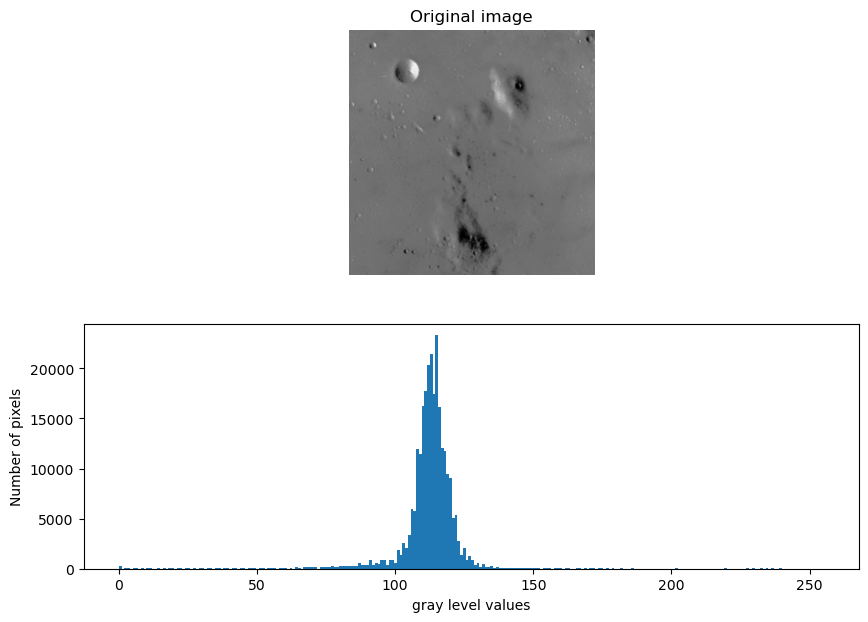

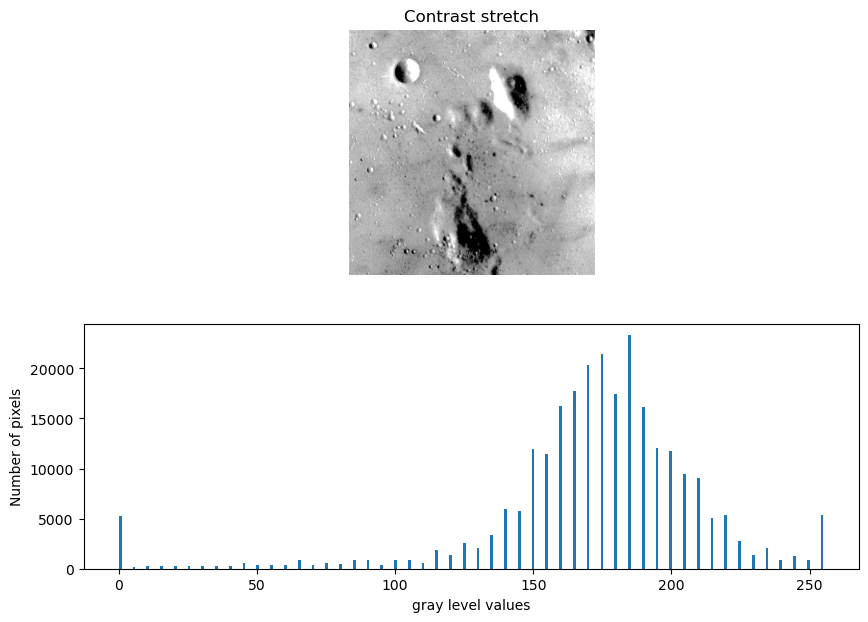

In [5]:
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Assessment

Task#1: Using the same ‘moon image’ Rescale intensity values to include all the intensities
that fall within the 3nd and 80th percentiles, and plot the histogram

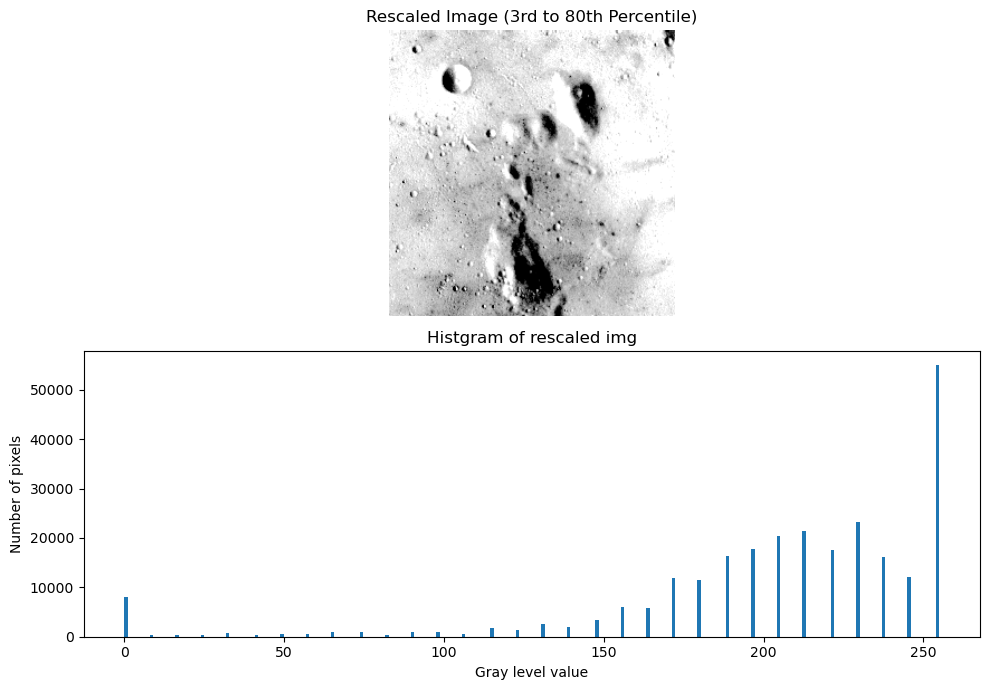

In [7]:
p3, p80 = np.percentile(img, (3, 80))

img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(10, 7))

fig.add_subplot(2, 1, 1) 
plt.imshow(img_rescale, cmap='gray')
plt.axis('off') 
plt.title('Rescaled Image (3rd to 80th Percentile)')

fig.add_subplot(2, 1, 2) 
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.title('Histgram of rescaled img')
plt.xlabel('Gray level value')
plt.ylabel('Number of pixels')

plt.tight_layout() 
plt.show()

Task#2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the
image and the histogram of the image after flattening the histogram.

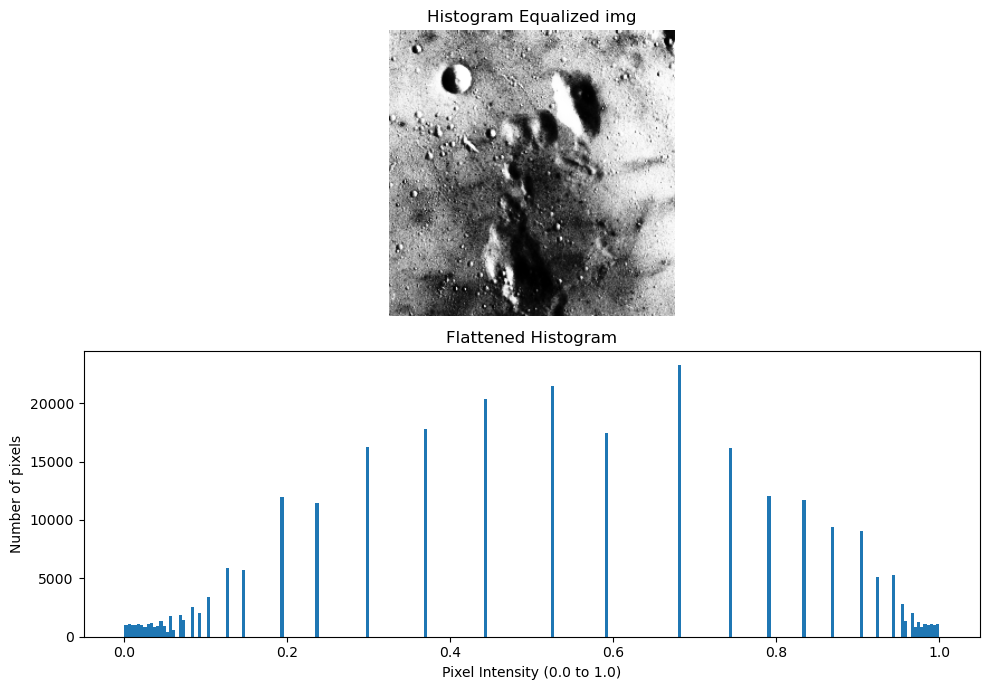

In [10]:
img_eq = exposure.equalize_hist(img)

fig = plt.figure(figsize=(10, 7))

fig.add_subplot(2, 1, 1) 
plt.imshow(img_eq, cmap='gray')
plt.axis('off') 
plt.title('Histogram Equalized img')

fig.add_subplot(2, 1, 2) 
plt.hist(img_eq.flat, bins=256, range=(0.0, 1.0))
plt.title('Flattened Histogram')
plt.xlabel('Pixel Intensity (0.0 to 1.0)')
plt.ylabel('Number of pixels')

plt.tight_layout() 
plt.show()

Task#3: Use the rocket (as reference) and chelsea images (from skimage.data) and
implement histogram matching

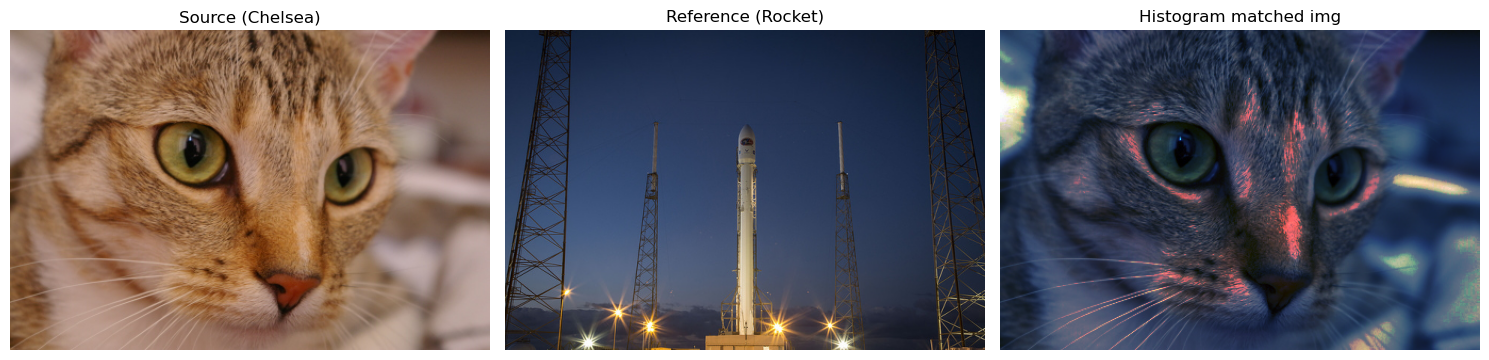

In [ ]:
source_img = data.chelsea()
reference_img = data.rocket()

matched_img = exposure.match_histograms(source_img, reference_img, channel_axis=-1)

fig = plt.figure(figsize=(15, 5))

fig.add_subplot(1, 3, 1) 
plt.imshow(source_img)
plt.title('Source (Chelsea)')
plt.axis('off') 

fig.add_subplot(1, 3, 2) 
plt.imshow(reference_img)
plt.title('Reference (Rocket)')
plt.axis('off')

fig.add_subplot(1, 3, 3) 
plt.imshow(matched_img)
plt.title('Histogram matched img')
plt.axis('off')

plt.tight_layout()
plt.show()